# Machine Learning Model for Predicting 3D Print Integrity

In [1]:
import os

import emlearn
import glob
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
import tensorflow as tf
import time

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

pd.options.display.float_format = '{:.3f}%'.format
pd.options.display.float_format = None
pd.set_option('display.float_format', lambda x: '%.4f' % x)

DATA_DIR = 'data'
FILE_PATTERN = os.path.join(DATA_DIR, '*.csv')
all_files = glob.glob(FILE_PATTERN)

<Figure size 800x600 with 0 Axes>

## Loading the Datasets

In [2]:
print("Starting to load the datasets...\n")

#    LOAD CORRECT TIME SERIES (OK Print)   

print("Loading Correct Time Series...")

correct_ts_0 = pd.read_csv(os.path.join(DATA_DIR, 'Correct_Time_Series_0.csv'))
correct_ts_1 = pd.read_csv(os.path.join(DATA_DIR, 'Correct_Time_Series_1.csv'))
correct_ts_2 = pd.read_csv(os.path.join(DATA_DIR, 'Correct_Time_Series_2.csv'))
correct_ts_3 = pd.read_csv(os.path.join(DATA_DIR, 'Correct_Time_Series_3.csv'))
correct_ts_4 = pd.read_csv(os.path.join(DATA_DIR, 'Correct_Time_Series_4.csv'))
correct_ts_5 = pd.read_csv(os.path.join(DATA_DIR, 'Correct_Time_Series_5.csv'))

print(f"Loaded 6 Correct Time Series.")


#   LOAD ERROR TIME SERIES (Print Failed)  

print("\nLoading Error Time Series...")

error_ts_0 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_0.csv'))
error_ts_1 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_1.csv'))
error_ts_2 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_2.csv'))
error_ts_3 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_3.csv'))
error_ts_4 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_4.csv'))
error_ts_5 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_5.csv'))
error_ts_6 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_6.csv'))
error_ts_7 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_7.csv'))
error_ts_8 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_8.csv'))
error_ts_9 = pd.read_csv(os.path.join(DATA_DIR, 'Error_Time_Series_9.csv'))

print(f"Loaded 10 Error Time Series.")

print("\nAll datasets loaded successfully into separate variables!")

datasets = {
    'Correct_0': correct_ts_0, 'Correct_1': correct_ts_1, 'Correct_2': correct_ts_2, 'Correct_3': correct_ts_3, 
    'Correct_4': correct_ts_4, 'Correct_5': correct_ts_5,
    'Error_0': error_ts_0,     'Error_1': error_ts_1,     'Error_2': error_ts_2,     'Error_3': error_ts_3,
    'Error_4': error_ts_4,     'Error_5': error_ts_5,     'Error_6': error_ts_6,     'Error_7': error_ts_7,
    'Error_8': error_ts_8,     'Error_9': error_ts_9
}

Starting to load the datasets...

Loading Correct Time Series...
Loaded 6 Correct Time Series.

Loading Error Time Series...
Loaded 10 Error Time Series.

All datasets loaded successfully into separate variables!


## Data Exploration

### Description

In [3]:
correct_ts_0.info()

<class 'pandas.DataFrame'>
RangeIndex: 106774 entries, 0 to 106773
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         106774 non-null  int64  
 1   X-Axis-plate      106774 non-null  float64
 2   Y-Axis-plate      106774 non-null  float64
 3   Z-Axis-plate      106774 non-null  float64
 4   X-Axis-extrusion  106774 non-null  float64
 5   Y-Axis-extrusion  106774 non-null  float64
 6   Z-Axis-extrusion  106774 non-null  float64
 7   Tension           106774 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 6.5 MB


In [4]:
feature_stats = correct_ts_0.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,106774.0000,-0.4067,0.3446,-1.1420,-0.7800,-0.1610,-0.1240,1.1490
Y-Axis-plate,106774.0000,-0.1825,0.1828,-2.3660,-0.1660,-0.1380,-0.1230,1.3280
Z-Axis-plate,106774.0000,9.6953,0.0692,7.3090,9.6730,9.6890,9.7130,12.9470
X-Axis-extrusion,106774.0000,0.2523,0.4848,-11.3220,0.1710,0.2400,0.3740,10.9330
Y-Axis-extrusion,106774.0000,0.3098,0.5220,-13.5970,0.2160,0.2750,0.4400,9.2520
Z-Axis-extrusion,106774.0000,-9.7764,0.2866,-16.5780,-9.8470,-9.7930,-9.6660,-0.3260
Tension,106774.0000,332.8330,68.0648,197.9000,244.9250,330.5000,401.4000,409.5000


In [5]:
correct_ts_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 72374 entries, 0 to 72373
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         72374 non-null  int64  
 1   X-Axis-plate      72374 non-null  float64
 2   Y-Axis-plate      72374 non-null  float64
 3   Z-Axis-plate      72374 non-null  float64
 4   X-Axis-extrusion  72374 non-null  float64
 5   Y-Axis-extrusion  72374 non-null  float64
 6   Z-Axis-extrusion  72374 non-null  float64
 7   Tension           72374 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 4.4 MB


In [6]:
feature_stats = correct_ts_1.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,72374.0000,-0.2411,0.2630,-0.9900,-0.2590,-0.1800,-0.1380,0.9900
Y-Axis-plate,72374.0000,-0.2319,0.2547,-1.6400,-0.2750,-0.1920,-0.1460,0.9900
Z-Axis-plate,72374.0000,9.6707,0.1202,6.8860,9.6220,9.6700,9.7170,11.9210
X-Axis-extrusion,72374.0000,0.2618,1.2189,-8.4800,-0.2280,0.3170,0.6710,9.8900
Y-Axis-extrusion,72374.0000,0.3338,1.2746,-9.6760,-0.1998,0.3770,0.7570,9.9650
Z-Axis-extrusion,72374.0000,-9.8541,0.6551,-17.8730,-10.2030,-9.8110,-9.5300,3.5690
Tension,72374.0000,324.1427,53.9198,205.6000,288.9500,351.2000,358.7000,387.5000


In [7]:
correct_ts_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 252995 entries, 0 to 252994
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         252995 non-null  int64  
 1   X-Axis-plate      252995 non-null  float64
 2   Y-Axis-plate      252995 non-null  float64
 3   Z-Axis-plate      252995 non-null  float64
 4   X-Axis-extrusion  252995 non-null  float64
 5   Y-Axis-extrusion  252995 non-null  float64
 6   Z-Axis-extrusion  252995 non-null  float64
 7   Tension           252995 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 15.4 MB


In [8]:
feature_stats = correct_ts_2.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,252995.0000,-0.2272,0.2178,-1.6510,-0.2460,-0.1890,-0.1520,1.1800
Y-Axis-plate,252995.0000,-0.2327,0.2295,-2.9200,-0.2700,-0.2000,-0.1570,2.2080
Z-Axis-plate,252995.0000,9.6452,0.1138,6.2660,9.5990,9.6440,9.6910,12.6340
X-Axis-extrusion,252995.0000,0.2649,1.2321,-19.9600,-0.2150,0.3020,0.6700,19.2860
Y-Axis-extrusion,252995.0000,0.3429,1.2592,-18.3160,-0.1730,0.3670,0.7530,17.7610
Z-Axis-extrusion,252995.0000,-9.8461,0.6555,-19.7100,-10.1810,-9.8170,-9.5380,7.9500
Tension,252995.0000,316.6194,52.6468,0.0000,240.1000,345.1000,352.5000,379.7000


In [9]:
correct_ts_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1336983 entries, 0 to 1336982
Data columns (total 8 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Timestamp         1336983 non-null  int64  
 1   X-Axis-plate      1336983 non-null  float64
 2   Y-Axis-plate      1336983 non-null  float64
 3   Z-Axis-plate      1336983 non-null  float64
 4   X-Axis-extrusion  1336983 non-null  float64
 5   Y-Axis-extrusion  1336983 non-null  float64
 6   Z-Axis-extrusion  1336983 non-null  float64
 7   Tension           1336983 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 81.6 MB


In [10]:
feature_stats = correct_ts_3.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,1336983.0000,-0.1979,0.1325,-2.2060,-0.2080,-0.1780,-0.1520,2.7200
Y-Axis-plate,1336983.0000,-0.2026,0.1323,-5.5360,-0.2170,-0.1870,-0.1600,6.3240
Z-Axis-plate,1336983.0000,9.6594,0.0722,2.6530,9.6320,9.6620,9.6900,14.5000
X-Axis-extrusion,1336983.0000,0.2539,0.6223,-9.8000,0.1250,0.2890,0.5010,11.6640
Y-Axis-extrusion,1336983.0000,0.3356,0.6547,-16.1350,0.1700,0.3580,0.5880,14.2370
Z-Axis-extrusion,1336983.0000,-9.8224,0.3935,-19.3050,-9.9340,-9.7860,-9.6360,3.5320
Tension,1336983.0000,352.8892,32.3017,207.4000,335.6000,351.0000,367.9000,409.5000


In [11]:
correct_ts_4.info()

<class 'pandas.DataFrame'>
RangeIndex: 197663 entries, 0 to 197662
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         197663 non-null  int64  
 1   X-Axis-plate      197663 non-null  float64
 2   Y-Axis-plate      197663 non-null  float64
 3   Z-Axis-plate      197663 non-null  float64
 4   X-Axis-extrusion  197663 non-null  float64
 5   Y-Axis-extrusion  197663 non-null  float64
 6   Z-Axis-extrusion  197663 non-null  float64
 7   Tension           197663 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 12.1 MB


In [12]:
feature_stats = correct_ts_4.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,197663.0000,-0.2316,0.2139,-2.8000,-0.2610,-0.2040,-0.1610,2.5000
Y-Axis-plate,197663.0000,-0.2388,0.2871,-6.7700,-0.2850,-0.2150,-0.1660,7.9000
Z-Axis-plate,197663.0000,9.6456,0.1503,3.5680,9.5940,9.6450,9.6950,13.8400
X-Axis-extrusion,197663.0000,0.2514,1.2273,-8.5250,-0.2530,0.3090,0.6780,9.6000
Y-Axis-extrusion,197663.0000,0.3448,1.2737,-9.8800,-0.1990,0.3820,0.7780,12.5470
Z-Axis-extrusion,197663.0000,-9.8133,0.6622,-71.3450,-10.1630,-9.7730,-9.4940,3.4250
Tension,197663.0000,329.9959,10.6259,0.0000,324.1000,330.8000,336.7000,360.3000


In [13]:
correct_ts_5.info()

<class 'pandas.DataFrame'>
RangeIndex: 137642 entries, 0 to 137641
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         137642 non-null  int64  
 1   X-Axis-plate      137642 non-null  float64
 2   Y-Axis-plate      137642 non-null  float64
 3   Z-Axis-plate      137642 non-null  float64
 4   X-Axis-extrusion  137642 non-null  float64
 5   Y-Axis-extrusion  137642 non-null  float64
 6   Z-Axis-extrusion  137642 non-null  float64
 7   Tension           137642 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 8.4 MB


In [14]:
feature_stats = correct_ts_5.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,137642.0000,-0.2282,0.1985,-1.9700,-0.2540,-0.2010,-0.1620,2.1830
Y-Axis-plate,137642.0000,-0.2389,0.2299,-5.9800,-0.2790,-0.2130,-0.1680,4.8590
Z-Axis-plate,137642.0000,9.6406,0.1114,6.4900,9.5930,9.6410,9.6870,14.5180
X-Axis-extrusion,137642.0000,0.2485,1.2191,-16.8910,-0.2300,0.2950,0.6540,18.7800
Y-Axis-extrusion,137642.0000,0.3258,1.2701,-13.7140,-0.1880,0.3540,0.7380,16.9070
Z-Axis-extrusion,137642.0000,-9.8346,0.6420,-19.1500,-10.1680,-9.8020,-9.5300,3.5100
Tension,137642.0000,328.5501,16.5636,0.0000,324.1000,331.3000,337.2000,362.0000


In [15]:
error_ts_0.info()

<class 'pandas.DataFrame'>
RangeIndex: 700461 entries, 0 to 700460
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         700461 non-null  int64  
 1   X-Axis-plate      700461 non-null  float64
 2   Y-Axis-plate      700461 non-null  float64
 3   Z-Axis-plate      700461 non-null  float64
 4   X-Axis-extrusion  700461 non-null  float64
 5   Y-Axis-extrusion  700461 non-null  float64
 6   Z-Axis-extrusion  700461 non-null  float64
 7   Tension           700461 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 42.8 MB


In [16]:
feature_stats = error_ts_0.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,700461.0000,-0.2560,0.2569,-1.4200,-0.1870,-0.1510,-0.1270,1.4500
Y-Axis-plate,700461.0000,-0.2190,0.2204,-4.1090,-0.1800,-0.1510,-0.1290,2.1510
Z-Axis-plate,700461.0000,9.6332,0.0506,3.3150,9.6090,9.6340,9.6570,12.5800
X-Axis-extrusion,700461.0000,0.2822,0.4406,-12.9600,0.1700,0.2990,0.4830,8.1920
Y-Axis-extrusion,700461.0000,0.3183,0.4752,-10.7980,0.1860,0.3330,0.5320,9.5960
Z-Axis-extrusion,700461.0000,-9.8874,0.3058,-17.6900,-9.9620,-9.8420,-9.7160,-0.6700
Tension,700461.0000,338.7865,36.5118,205.5000,323.4000,336.6000,349.4000,409.5000


In [17]:
error_ts_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 511733 entries, 0 to 511732
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         511733 non-null  int64  
 1   X-Axis-plate      511733 non-null  float64
 2   Y-Axis-plate      511733 non-null  float64
 3   Z-Axis-plate      511733 non-null  float64
 4   X-Axis-extrusion  511733 non-null  float64
 5   Y-Axis-extrusion  511733 non-null  float64
 6   Z-Axis-extrusion  511733 non-null  float64
 7   Tension           511733 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 31.2 MB


In [18]:
feature_stats = error_ts_1.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,511733.0000,-0.2045,0.1743,-1.1500,-0.1960,-0.1670,-0.1420,2.8200
Y-Axis-plate,511733.0000,-0.2060,0.1857,-3.3100,-0.1990,-0.1670,-0.1420,3.5160
Z-Axis-plate,511733.0000,9.6013,0.0724,6.8120,9.5720,9.6010,9.6300,13.1340
X-Axis-extrusion,511733.0000,0.2816,0.7001,-8.9150,0.1160,0.3270,0.5630,10.4360
Y-Axis-extrusion,511733.0000,0.3221,0.7402,-8.9000,0.1230,0.3640,0.6240,10.8330
Z-Axis-extrusion,511733.0000,-9.9113,0.4642,-18.1840,-10.1570,-9.8580,-9.6700,3.3700
Tension,511733.0000,348.6563,22.7360,294.0000,331.0000,343.8000,371.1000,406.4000


In [19]:
error_ts_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 125956 entries, 0 to 125955
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         125956 non-null  int64  
 1   X-Axis-plate      125956 non-null  float64
 2   Y-Axis-plate      125956 non-null  float64
 3   Z-Axis-plate      125956 non-null  float64
 4   X-Axis-extrusion  125956 non-null  float64
 5   Y-Axis-extrusion  125956 non-null  float64
 6   Z-Axis-extrusion  125956 non-null  float64
 7   Tension           125956 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 7.7 MB


In [20]:
feature_stats = error_ts_2.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,125956.0000,-0.2327,0.2472,-0.9900,-0.2500,-0.1810,-0.1410,0.9900
Y-Axis-plate,125956.0000,-0.2349,0.2711,-1.5430,-0.2810,-0.1890,-0.1410,0.9900
Z-Axis-plate,125956.0000,9.5972,0.1059,7.9160,9.5510,9.5970,9.6430,11.8560
X-Axis-extrusion,125956.0000,0.2785,1.2306,-8.1600,-0.2200,0.3290,0.6940,9.6000
Y-Axis-extrusion,125956.0000,0.3132,1.2925,-10.9600,-0.2230,0.3590,0.7480,10.5300
Z-Axis-extrusion,125956.0000,-9.9061,0.6534,-18.2100,-10.2480,-9.8590,-9.5870,2.4240
Tension,125956.0000,311.1143,49.8836,207.6000,255.5750,337.5000,343.2000,366.9000


In [21]:
error_ts_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 171360 entries, 0 to 171359
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         171360 non-null  int64  
 1   X-Axis-plate      171360 non-null  float64
 2   Y-Axis-plate      171360 non-null  float64
 3   Z-Axis-plate      171360 non-null  float64
 4   X-Axis-extrusion  171360 non-null  float64
 5   Y-Axis-extrusion  171360 non-null  float64
 6   Z-Axis-extrusion  171360 non-null  float64
 7   Tension           171360 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 10.5 MB


In [22]:
feature_stats = error_ts_3.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,171360.0000,-0.2309,0.2423,-1.6250,-0.2470,-0.1810,-0.1420,0.9900
Y-Axis-plate,171360.0000,-0.2350,0.2645,-1.9200,-0.2780,-0.1890,-0.1420,1.2940
Z-Axis-plate,171360.0000,9.5943,0.1046,7.8250,9.5490,9.5950,9.6390,11.8800
X-Axis-extrusion,171360.0000,0.2748,1.2399,-8.7400,-0.2300,0.3270,0.6950,9.3650
Y-Axis-extrusion,171360.0000,0.3059,1.2971,-10.4570,-0.2360,0.3510,0.7430,9.5320
Z-Axis-extrusion,171360.0000,-9.9113,0.6527,-18.3900,-10.2500,-9.8620,-9.5920,3.2710
Tension,171360.0000,310.4538,49.6258,206.0000,249.9000,337.1000,342.2000,362.6000


In [23]:
error_ts_4.info()

<class 'pandas.DataFrame'>
RangeIndex: 302739 entries, 0 to 302738
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         302739 non-null  int64  
 1   X-Axis-plate      302739 non-null  float64
 2   Y-Axis-plate      302739 non-null  float64
 3   Z-Axis-plate      302739 non-null  float64
 4   X-Axis-extrusion  302739 non-null  float64
 5   Y-Axis-extrusion  302739 non-null  float64
 6   Z-Axis-extrusion  302739 non-null  float64
 7   Tension           302739 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 18.5 MB


In [24]:
feature_stats = error_ts_4.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,302739.0000,-0.2392,0.2516,-1.7600,-0.1730,-0.1480,-0.1280,0.9600
Y-Axis-plate,302739.0000,-0.1709,0.1154,-1.7020,-0.1750,-0.1540,-0.1340,1.3450
Z-Axis-plate,302739.0000,9.9850,170.2315,1.7360,9.6560,9.6740,9.6950,93674.0000
X-Axis-extrusion,302739.0000,0.2791,0.3570,-12.1770,0.1860,0.2760,0.4320,7.6060
Y-Axis-extrusion,302739.0000,0.3397,0.3675,-10.5000,0.2270,0.3210,0.4960,8.6540
Z-Axis-extrusion,302739.0000,-9.8130,0.2454,-18.4270,-9.8770,-9.8030,-9.6950,0.2420
Tension,302739.0000,334.8204,58.0385,197.1000,310.0000,319.5000,394.5000,409.5000


In [25]:
error_ts_5.info()

<class 'pandas.DataFrame'>
RangeIndex: 1242058 entries, 0 to 1242057
Data columns (total 8 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Timestamp         1242058 non-null  int64  
 1   X-Axis-plate      1242058 non-null  float64
 2   Y-Axis-plate      1242058 non-null  float64
 3   Z-Axis-plate      1242058 non-null  float64
 4   X-Axis-extrusion  1242058 non-null  float64
 5   Y-Axis-extrusion  1242058 non-null  float64
 6   Z-Axis-extrusion  1242058 non-null  float64
 7   Tension           1242058 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 75.8 MB


In [26]:
feature_stats = error_ts_5.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,1242058.0000,-0.1924,0.1126,-9.5570,-0.2060,-0.1810,-0.1590,10.4500
Y-Axis-plate,1242058.0000,-0.1959,0.1291,-10.1000,-0.2070,-0.1820,-0.1600,20.1320
Z-Axis-plate,1242058.0000,9.6353,0.0857,-15.9710,9.6100,9.6360,9.6620,19.5990
X-Axis-extrusion,1242058.0000,0.2837,0.5742,-15.3380,0.1490,0.3140,0.5200,19.4140
Y-Axis-extrusion,1242058.0000,0.3596,0.6061,-16.7870,0.1900,0.3810,0.6000,19.5990
Z-Axis-extrusion,1242058.0000,-9.8540,0.3704,-19.2850,-9.9520,-9.8130,-9.6720,2.4500
Tension,1242058.0000,352.2475,30.3804,193.6000,331.3000,351.8000,375.5000,409.5000


In [27]:
error_ts_6.info()

<class 'pandas.DataFrame'>
RangeIndex: 127633 entries, 0 to 127632
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         127633 non-null  int64  
 1   X-Axis-plate      127633 non-null  float64
 2   Y-Axis-plate      127633 non-null  float64
 3   Z-Axis-plate      127633 non-null  float64
 4   X-Axis-extrusion  127633 non-null  float64
 5   Y-Axis-extrusion  127633 non-null  float64
 6   Z-Axis-extrusion  127633 non-null  float64
 7   Tension           127633 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 7.8 MB


In [28]:
feature_stats = error_ts_6.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,127633.0000,-0.2283,0.2134,-1.9100,-0.2520,-0.1950,-0.1550,1.3040
Y-Axis-plate,127633.0000,-0.2355,0.2255,-1.4700,-0.2740,-0.2040,-0.1580,1.4010
Z-Axis-plate,127633.0000,9.6237,0.1195,6.6510,9.5760,9.6230,9.6700,12.8680
X-Axis-extrusion,127633.0000,0.2728,1.2407,-8.3340,-0.2370,0.3250,0.7000,9.9230
Y-Axis-extrusion,127633.0000,0.3536,1.2928,-9.6840,-0.1930,0.3920,0.7820,9.9660
Z-Axis-extrusion,127633.0000,-9.8578,0.6472,-18.9200,-10.2050,-9.8140,-9.5360,3.4400
Tension,127633.0000,315.1302,50.3328,213.3000,260.6000,341.5000,347.8000,369.4000


In [29]:
error_ts_7.info()

<class 'pandas.DataFrame'>
RangeIndex: 304056 entries, 0 to 304055
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         304056 non-null  int64  
 1   X-Axis-plate      304056 non-null  float64
 2   Y-Axis-plate      304056 non-null  float64
 3   Z-Axis-plate      304056 non-null  float64
 4   X-Axis-extrusion  304056 non-null  float64
 5   Y-Axis-extrusion  304056 non-null  float64
 6   Z-Axis-extrusion  304056 non-null  float64
 7   Tension           304056 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 18.6 MB


In [30]:
feature_stats = error_ts_7.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,304056.0000,-0.2181,0.1872,-0.9900,-0.2340,-0.1850,-0.1620,1.2350
Y-Axis-plate,304056.0000,-0.2269,0.1998,-1.1400,-0.2510,-0.1920,-0.1680,0.9900
Z-Axis-plate,304056.0000,9.6194,0.1031,7.1300,9.5810,9.6200,9.6550,12.8900
X-Axis-extrusion,304056.0000,0.2653,1.1295,-8.9580,-0.1290,0.2600,0.5990,12.6600
Y-Axis-extrusion,304056.0000,0.3378,1.1629,-11.3220,0.1070,0.3160,0.6770,10.3730
Z-Axis-extrusion,304056.0000,-9.8613,0.5798,-18.1600,-10.1240,-9.8410,-9.6150,3.4990
Tension,304056.0000,301.2080,54.3958,211.9000,234.6000,337.9000,345.9000,369.3000


In [31]:
error_ts_8.info()

<class 'pandas.DataFrame'>
RangeIndex: 354827 entries, 0 to 354826
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         354827 non-null  int64  
 1   X-Axis-plate      354827 non-null  float64
 2   Y-Axis-plate      354827 non-null  float64
 3   Z-Axis-plate      354827 non-null  float64
 4   X-Axis-extrusion  354827 non-null  float64
 5   Y-Axis-extrusion  354827 non-null  float64
 6   Z-Axis-extrusion  354827 non-null  float64
 7   Tension           354827 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 21.7 MB


In [32]:
feature_stats = error_ts_8.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,354827.0000,-0.2489,0.2551,-0.9900,-0.1820,-0.1510,-0.1300,1.2820
Y-Axis-plate,354827.0000,-0.1879,0.1569,-1.9000,-0.1810,-0.1550,-0.1310,3.1250
Z-Axis-plate,354827.0000,9.6713,0.0553,2.9790,9.6510,9.6700,9.6900,13.2620
X-Axis-extrusion,354827.0000,0.2658,0.3725,-9.1730,0.1690,0.2690,0.4400,11.5610
Y-Axis-extrusion,354827.0000,0.3449,0.3667,-16.8590,0.2230,0.3330,0.5050,7.7800
Z-Axis-extrusion,354827.0000,-9.7942,0.2557,-16.9200,-9.8700,-9.7880,-9.6640,0.1560
Tension,354827.0000,288.3273,77.4345,188.9000,230.3000,236.1000,391.2000,409.5000


In [33]:
error_ts_9.info()

<class 'pandas.DataFrame'>
RangeIndex: 826126 entries, 0 to 826125
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Timestamp         826126 non-null  int64  
 1   X-Axis-plate      826126 non-null  float64
 2   Y-Axis-plate      826126 non-null  float64
 3   Z-Axis-plate      826126 non-null  float64
 4   X-Axis-extrusion  826126 non-null  float64
 5   Y-Axis-extrusion  826126 non-null  float64
 6   Z-Axis-extrusion  826126 non-null  float64
 7   Tension           826126 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 50.4 MB


In [34]:
feature_stats = error_ts_9.drop(columns=['Timestamp']).describe().T
display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
X-Axis-plate,826126.0000,-0.2375,0.2620,-15.5490,-0.1920,-0.1560,-0.1310,17.1970
Y-Axis-plate,826126.0000,-0.1926,0.1917,-18.2880,-0.1930,-0.1660,-0.1420,16.1670
Z-Axis-plate,826126.0000,9.6657,0.1355,-6.9870,9.6390,9.6660,9.6930,18.4400
X-Axis-extrusion,826126.0000,0.2675,0.5626,-19.3690,0.1430,0.3000,0.5000,16.9830
Y-Axis-extrusion,826126.0000,0.3365,0.5627,-18.5750,0.1820,0.3590,0.5650,18.2240
Z-Axis-extrusion,826126.0000,-9.8258,0.3682,-19.4920,-9.9270,-9.7890,-9.6480,7.9160
Tension,826126.0000,351.6031,30.7551,193.2000,332.0000,349.3000,371.5000,409.5000


In [35]:
del feature_stats

### Measurement Time for Sensors

In [36]:
print("Calculating sampling intervals (Time Delta)...\n")

# Variables to keep track of totals for the exact global average
total_time_diff_sum = 0
total_intervals_count = 0

# List to store individual dataset statistics
sampling_results = []

for name, df in datasets.items():
    # Calculate the difference in milliseconds between consecutive rows
    # .dropna() removes the NaN generated in the first row
    time_diffs = df['Timestamp'].diff().dropna()
    
    # Calculate local mean and standard deviation
    mean_diff = time_diffs.mean()
    std_diff = time_diffs.std() # Useful to see how stable the sensor's clock is
    
    # Update global counters
    total_time_diff_sum += time_diffs.sum()
    total_intervals_count += len(time_diffs)
    
    # Store the result for this specific file
    sampling_results.append({
        'Dataset': name,
        'Total_Rows': len(df),
        'Mean_Interval_ms': mean_diff,
        'Std_Interval_ms': std_diff
    })

# Convert the results into a DataFrame for a nice tabular visualization
df_sampling_stats = pd.DataFrame(sampling_results)

# Force standard floating-point format (no scientific notation)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Display the table
display(df_sampling_stats)

# Calculate and print the global metrics
if total_intervals_count > 0:
    global_average_ms = total_time_diff_sum / total_intervals_count
    global_frequency_hz = 1000 / global_average_ms
    
    print("\n" + "="*50)
    print(f"Global Average Sampling Interval: {global_average_ms:.4f} ms")
    print(f"Estimated Global Sampling Frequency: {global_frequency_hz:.2f} Hz")
    print("="*50)

Calculating sampling intervals (Time Delta)...



,Dataset,Total_Rows,Mean_Interval_ms,Std_Interval_ms
0,Correct_0,106774,5.0137,7.3249
1,Correct_1,72374,4.9999,1.2643
2,Correct_2,252995,6.2530,611.7097
3,Correct_3,1336983,5.0332,28.4936
4,Correct_4,197663,5.0332,6.7343
5,Correct_5,137642,5.0276,6.0712
6,Error_0,700461,5.2038,70.3128
7,Error_1,511733,5.0164,5.3161
8,Error_2,125956,5.8705,157.2621
9,Error_3,171360,5.1771,61.7653



Global Average Sampling Interval: 5.1103 ms
Estimated Global Sampling Frequency: 195.68 Hz


Visualizing raw signal differences...


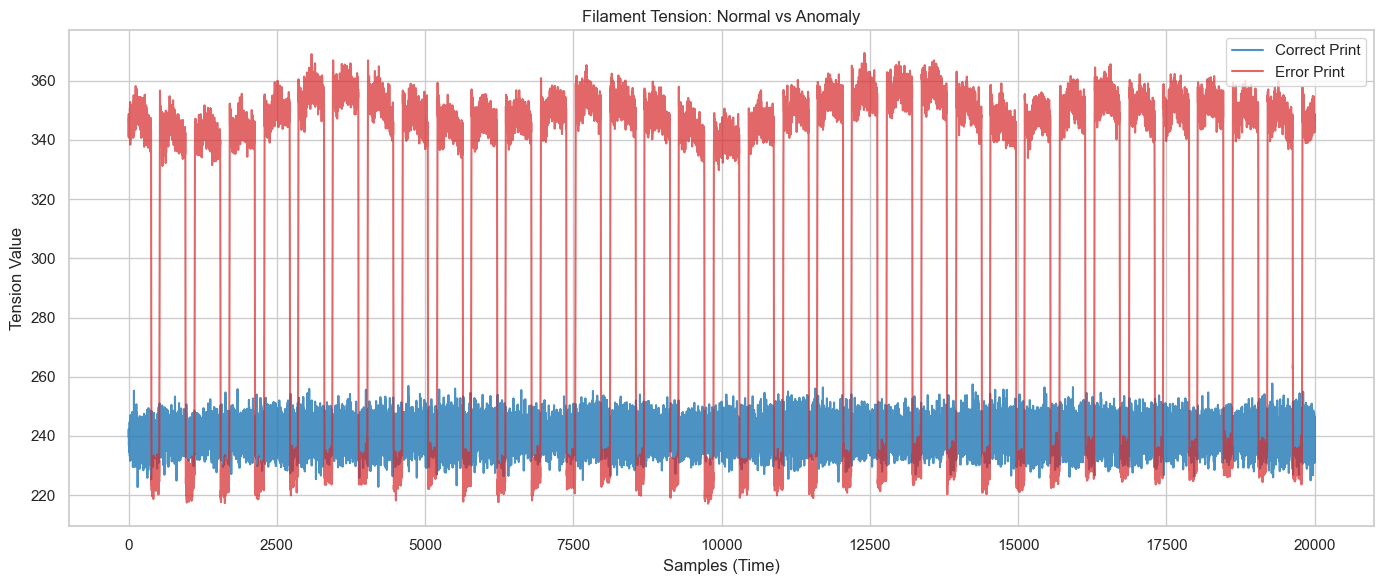

In [37]:
print("Visualizing raw signal differences...")

# Select a small slice to clearly see the waveform without overloading memory
slice_start = 10000
slice_end = 30000

fig, ax = plt.subplots(1, 1, figsize=(14, 6), sharex=True)

ax.plot(correct_ts_0['Tension'][slice_start:slice_end].values, 
        label='Correct Print', color='#1f77b4', alpha=0.8)

ax.plot(error_ts_6['Tension'][slice_start:slice_end].values, 
        label='Error Print', color='#d62728', alpha=0.7)

ax.set_title('Filament Tension: Normal vs Anomaly')
ax.set_ylabel('Tension Value')
ax.set_xlabel('Samples (Time)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Visualizing raw signal differences...


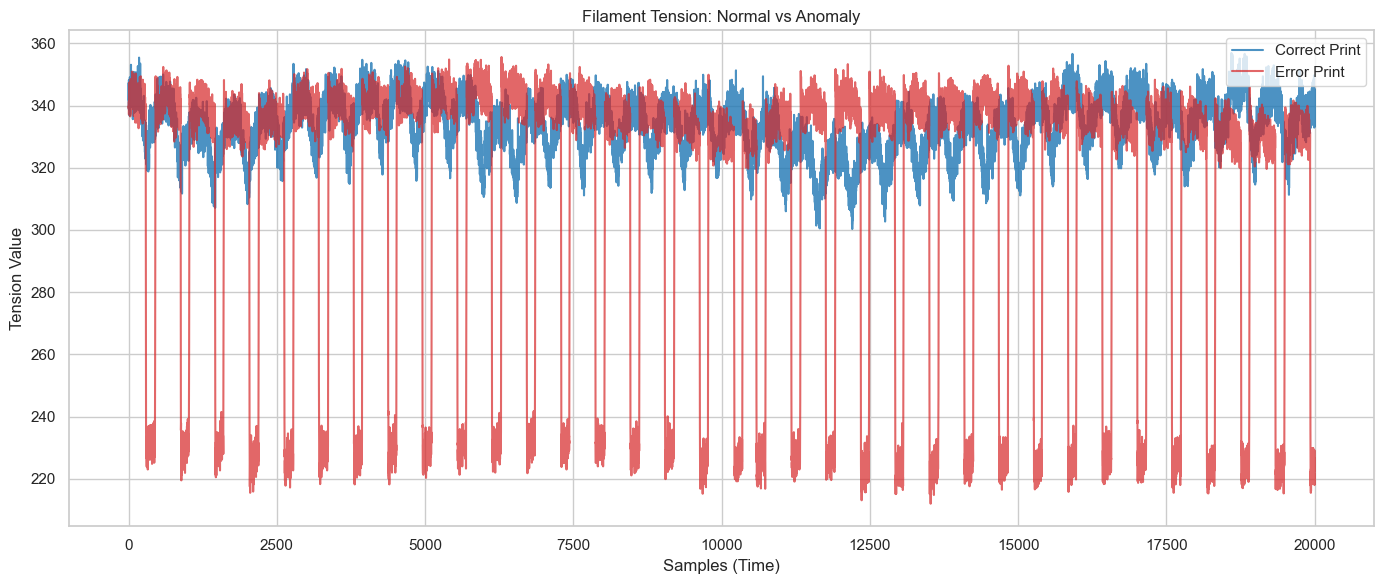

In [38]:
print("Visualizing raw signal differences...")
fig, ax = plt.subplots(1, 1, figsize=(14, 6), sharex=True)

ax.plot(correct_ts_4['Tension'][slice_start:slice_end].values, 
        label='Correct Print', color='#1f77b4', alpha=0.8)

ax.plot(error_ts_3['Tension'][slice_start:slice_end].values, 
        label='Error Print', color='#d62728', alpha=0.7)

ax.set_title('Filament Tension: Normal vs Anomaly')
ax.set_ylabel('Tension Value')
ax.set_xlabel('Samples (Time)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Statistical Distributions and Outliers

Analyzing statistical distributions and outliers...


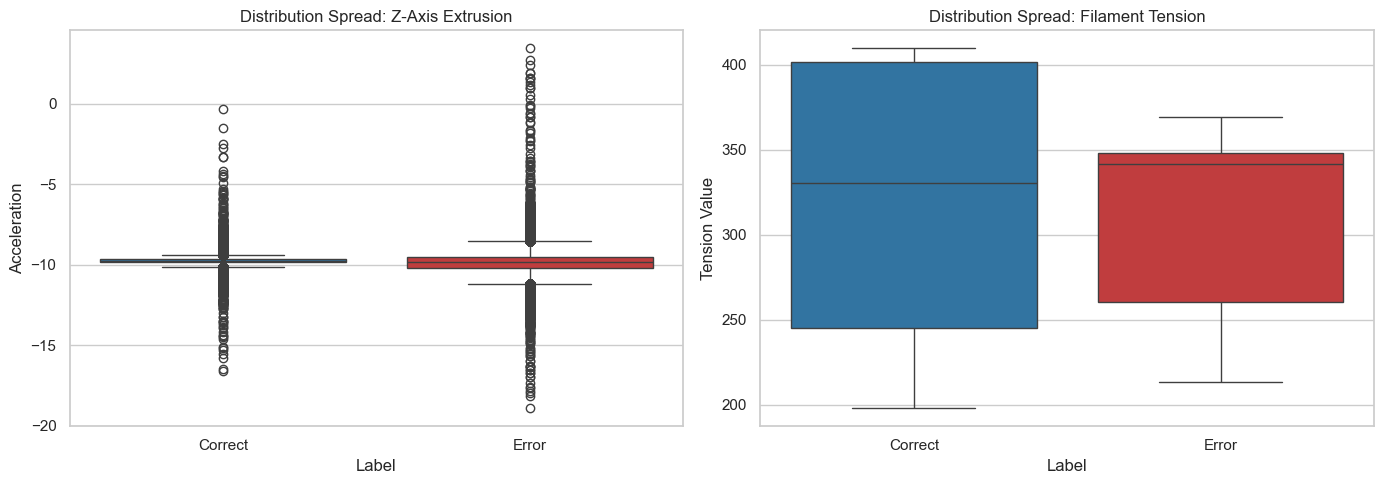

In [39]:
print("Analyzing statistical distributions and outliers...")

# Create a temporary DataFrame combining a sample of Correct and Error data
# We use only two key sensors to keep the memory footprint low
df_correct_sample = correct_ts_0[['Z-Axis-extrusion', 'Tension']].copy()
df_correct_sample['Label'] = 'Correct'

df_error_sample = error_ts_6[['Z-Axis-extrusion', 'Tension']].copy()
df_error_sample['Label'] = 'Error'

# Combine the dataframes
df_combined = pd.concat([df_correct_sample, df_error_sample])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: Z-Axis Extrusion
sns.boxplot(
    data=df_combined,
    x='Label',
    y='Z-Axis-extrusion',
    hue='Label',
    ax=axes[0],
    palette={'Correct': '#1f77b4', 'Error': '#d62728'},
    legend=False
)
axes[0].set_title('Distribution Spread: Z-Axis Extrusion')
axes[0].set_ylabel('Acceleration')

# Boxplot: Filament Tension
sns.boxplot(
    data=df_combined,
    x='Label',
    y='Tension',
    hue='Label',
    ax=axes[1],
    palette={'Correct': '#1f77b4', 'Error': '#d62728'},
    legend=False
)
axes[1].set_title('Distribution Spread: Filament Tension')
axes[1].set_ylabel('Tension Value')

plt.tight_layout()
plt.show()

# Clean up memory
del df_correct_sample, df_error_sample, df_combined

Analyzing statistical distributions and outliers...


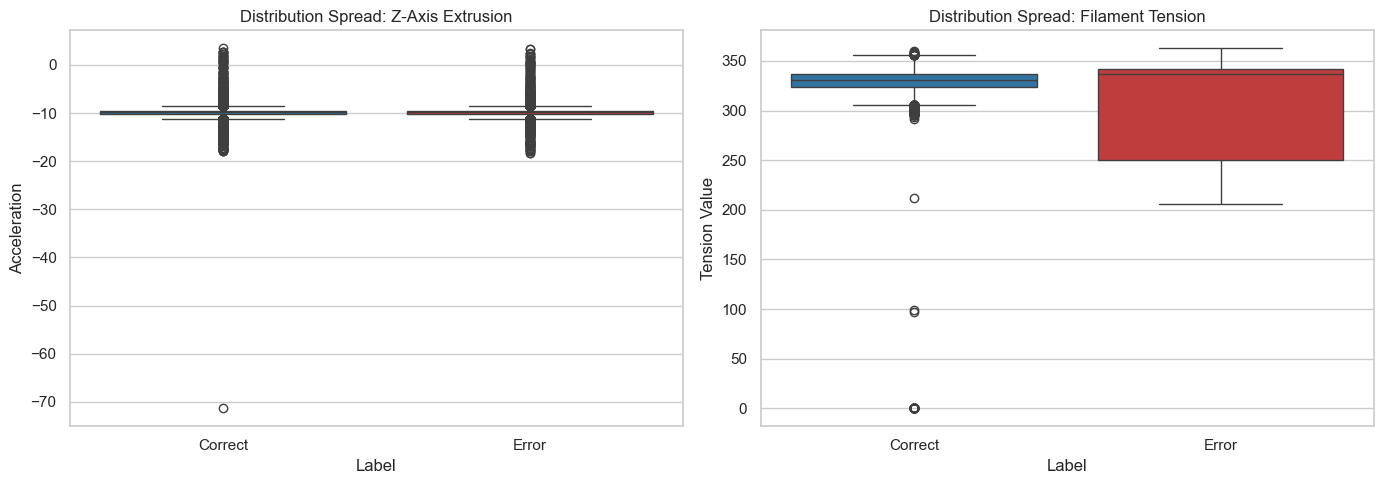

In [40]:
print("Analyzing statistical distributions and outliers...")

# Create a temporary DataFrame combining a sample of Correct and Error data
# We use only two key sensors to keep the memory footprint low
df_correct_sample = correct_ts_4[['Z-Axis-extrusion', 'Tension']].copy()
df_correct_sample['Label'] = 'Correct'

df_error_sample = error_ts_3[['Z-Axis-extrusion', 'Tension']].copy()
df_error_sample['Label'] = 'Error'

# Combine the dataframes
df_combined = pd.concat([df_correct_sample, df_error_sample])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: Z-Axis Extrusion
sns.boxplot(
    data=df_combined,
    x='Label',
    y='Z-Axis-extrusion',
    hue='Label',
    ax=axes[0],
    palette={'Correct': '#1f77b4', 'Error': '#d62728'},
    legend=False
)
axes[0].set_title('Distribution Spread: Z-Axis Extrusion')
axes[0].set_ylabel('Acceleration')

# Boxplot: Filament Tension
sns.boxplot(
    data=df_combined,
    x='Label',
    y='Tension',
    hue='Label',
    ax=axes[1],
    palette={'Correct': '#1f77b4', 'Error': '#d62728'},
    legend=False
)
axes[1].set_title('Distribution Spread: Filament Tension')
axes[1].set_ylabel('Tension Value')

plt.tight_layout()
plt.show()

# Clean up memory
del df_correct_sample, df_error_sample, df_combined

## Data Preprocessing

In [41]:
# We filter the DataFrame using a boolean condition
target_condition = error_ts_4['Z-Axis-plate'] == 93674
target_row = error_ts_4[target_condition]

# Display the found row
print("Row with Z-Axis-plate = 93674:")
display(target_row)

# Fix the outlier by scaling it down (assuming it's a unit error, we divide by 10000)
error_ts_4.loc[target_condition, 'Z-Axis-plate'] = error_ts_4.loc[target_condition, 'Z-Axis-plate'] / 10000

display(error_ts_4.describe().T)

Row with Z-Axis-plate = 93674:


,Timestamp,X-Axis-plate,Y-Axis-plate,Z-Axis-plate,X-Axis-extrusion,Y-Axis-extrusion,Z-Axis-extrusion,Tension
9925,1572428338748,-0.1040,-0.1250,93674.0000,0.2600,0.2540,-9.8610,235.6000


,count,mean,std,min,25%,50%,75%,max
Timestamp,302739.0000,1572429045994.2834,437060.2933,1572428289099.0000,1572428667519.5000,1572429045922.0000,1572429424366.5000,1572429814303.0000
X-Axis-plate,302739.0000,-0.2392,0.2516,-1.7600,-0.1730,-0.1480,-0.1280,0.9600
Y-Axis-plate,302739.0000,-0.1709,0.1154,-1.7020,-0.1750,-0.1540,-0.1340,1.3450
Z-Axis-plate,302739.0000,9.6757,0.0520,1.7360,9.6560,9.6740,9.6950,13.4850
X-Axis-extrusion,302739.0000,0.2791,0.3570,-12.1770,0.1860,0.2760,0.4320,7.6060
Y-Axis-extrusion,302739.0000,0.3397,0.3675,-10.5000,0.2270,0.3210,0.4960,8.6540
Z-Axis-extrusion,302739.0000,-9.8130,0.2454,-18.4270,-9.8770,-9.8030,-9.6950,0.2420
Tension,302739.0000,334.8204,58.0385,197.1000,310.0000,319.5000,394.5000,409.5000


In [42]:
# Create a list of the DataFrames you want to modify
dataframes_to_clean = [correct_ts_2, correct_ts_5]

# Loop through each DataFrame to drop rows where Tension is below 200
for df in dataframes_to_clean:
    # Identify rows where 'Tension' is less than 200 and put them to 200
    df.loc[df['Tension'] < 200, 'Tension'] = 200

    # Display the transposed description for each cleaned DataFrame
    print(f"Description for cleaned DataFrame:")
    display(df.describe().T)

Description for cleaned DataFrame:


,count,mean,std,min,25%,50%,75%,max
Timestamp,252995.0000,1573819516136.4399,461474.8400,1573818631465.0000,1573819255383.5000,1573819576707.0000,1573819895825.5000,1573820213426.0000
X-Axis-plate,252995.0000,-0.2272,0.2178,-1.6510,-0.2460,-0.1890,-0.1520,1.1800
Y-Axis-plate,252995.0000,-0.2327,0.2295,-2.9200,-0.2700,-0.2000,-0.1570,2.2080
Z-Axis-plate,252995.0000,9.6452,0.1138,6.2660,9.5990,9.6440,9.6910,12.6340
X-Axis-extrusion,252995.0000,0.2649,1.2321,-19.9600,-0.2150,0.3020,0.6700,19.2860
Y-Axis-extrusion,252995.0000,0.3429,1.2592,-18.3160,-0.1730,0.3670,0.7530,17.7610
Z-Axis-extrusion,252995.0000,-9.8461,0.6555,-19.7100,-10.1810,-9.8170,-9.5380,7.9500
Tension,252995.0000,316.6397,52.5696,200.0000,240.1000,345.1000,352.5000,379.7000


Description for cleaned DataFrame:


,count,mean,std,min,25%,50%,75%,max
Timestamp,137642.0000,1575295582821.0659,199893.6842,1575295236176.0000,1575295410794.2500,1575295582841.5000,1575295756133.0000,1575295928181.0000
X-Axis-plate,137642.0000,-0.2282,0.1985,-1.9700,-0.2540,-0.2010,-0.1620,2.1830
Y-Axis-plate,137642.0000,-0.2389,0.2299,-5.9800,-0.2790,-0.2130,-0.1680,4.8590
Z-Axis-plate,137642.0000,9.6406,0.1114,6.4900,9.5930,9.6410,9.6870,14.5180
X-Axis-extrusion,137642.0000,0.2485,1.2191,-16.8910,-0.2300,0.2950,0.6540,18.7800
Y-Axis-extrusion,137642.0000,0.3258,1.2701,-13.7140,-0.1880,0.3540,0.7380,16.9070
Z-Axis-extrusion,137642.0000,-9.8346,0.6420,-19.1500,-10.1680,-9.8020,-9.5300,3.5100
Tension,137642.0000,328.6011,15.8713,200.0000,324.1000,331.3000,337.2000,362.0000


## Models Construction

## Introduction

In [43]:
# DEFINE CONFIGURATIONS TO TEST 
window_configs = [
    # --- 1.0 Second Window (195 samples) ---
    # {'name': '1.0_Sec_00%_Overlap',  'window_size': 195,  'step_size': 195},
    # {'name': '1.0_Sec_10%_Overlap',  'window_size': 195,  'step_size': 175},
    # {'name': '1.0_Sec_25%_Overlap',  'window_size': 195,  'step_size': 145},
    # {'name': '1.0_Sec_50%_Overlap',  'window_size': 195,  'step_size': 95},
    
    # --- 5.0 Seconds Window (980 samples) ---
    {'name': '5.0_Sec_00%_Overlap',  'window_size': 980, 'step_size': 980},
    {'name': '5.0_Sec_10%_Overlap',  'window_size': 980, 'step_size': 880},
    {'name': '5.0_Sec_25%_Overlap',  'window_size': 980, 'step_size': 730},
    {'name': '5.0_Sec_50%_Overlap',  'window_size': 980, 'step_size': 490}

    # --- 10.0 Seconds Window (1955 samples) ---
    # {'name': '10.0_Sec_00%_Overlap',  'window_size': 1955, 'step_size': 1955},
    # {'name': '10.0_Sec_10%_Overlap',  'window_size': 1955, 'step_size': 1760},
    # {'name': '10.0_Sec_25%_Overlap',  'window_size': 1955, 'step_size': 1465},
    # {'name': '10.0_Sec_50%_Overlap',  'window_size': 1955, 'step_size': 975},

    # --- 15.0 Seconds Window (2935 samples) ---
    # {'name': '15.0_Sec_00%_Overlap',  'window_size': 2935, 'step_size': 2935},
    # {'name': '15.0_Sec_10%_Overlap',  'window_size': 2935, 'step_size': 2640},
    # {'name': '15.0_Sec_25%_Overlap',  'window_size': 2935, 'step_size': 2200},
    # {'name': '15.0_Sec_50%_Overlap',  'window_size': 2935, 'step_size': 1465}
]

sensor_cols = [
    'X-Axis-plate', 'Y-Axis-plate', 'Z-Axis-plate', 
    'X-Axis-extrusion', 'Y-Axis-extrusion', 'Z-Axis-extrusion', 
    'Tension'
]

# STRICT TRAIN / TEST DATA SPLIT
# (Make sure correct_ts_* and error_ts_* are defined before this cell)
correct_train_list = [correct_ts_1, correct_ts_2, correct_ts_3, correct_ts_5]
error_train_list = [error_ts_0, error_ts_1, error_ts_2, error_ts_4, error_ts_5, error_ts_7, error_ts_8, error_ts_9]

correct_test_list = [correct_ts_0, correct_ts_4]
error_test_list = [error_ts_3, error_ts_6]

cv_strategy = GroupKFold(n_splits=5)

# HELPER FUNCTION: FEATURE EXTRACTION
def extract_features_for_tuning(df_list, label, w_size, s_size, start_group_id=0):

    all_windows = []
    group_id = start_group_id

    for df in df_list:

        data_array = df[sensor_cols].values

        for start in range(0, len(data_array) - w_size + 1, s_size):

            end = start + w_size
            window = data_array[start:end]

            w_max = np.max(window, axis=0)
            w_min = np.min(window, axis=0)
            w_mean = np.mean(window, axis=0)
            w_std = np.std(window, axis=0)
            w_ptp = w_max - w_min

            feat_dict = {
                'Label': label,
                'Group': group_id
            }

            for i, col in enumerate(sensor_cols):
                feat_dict[f'{col}_mean'] = w_mean[i]
                feat_dict[f'{col}_std'] = w_std[i]
                feat_dict[f'{col}_max'] = w_max[i]
                feat_dict[f'{col}_min'] = w_min[i]
                feat_dict[f'{col}_ptp'] = w_ptp[i]

            all_windows.append(feat_dict)

        group_id += 1

    return all_windows, group_id

TRAIN SET:
  Correct Print Tuples : 1799994
  Error Print Tuples   : 4367956
  Disparity            : 2567962 tuples

TEST SET:
  Correct Print Tuples : 304437
  Error Print Tuples   : 298993
  Disparity            : 5444 tuples

OVERALL:
  Total Correct Tuples : 2104431 (31.08%)
  Total Error Tuples   : 4666949 (68.92%)


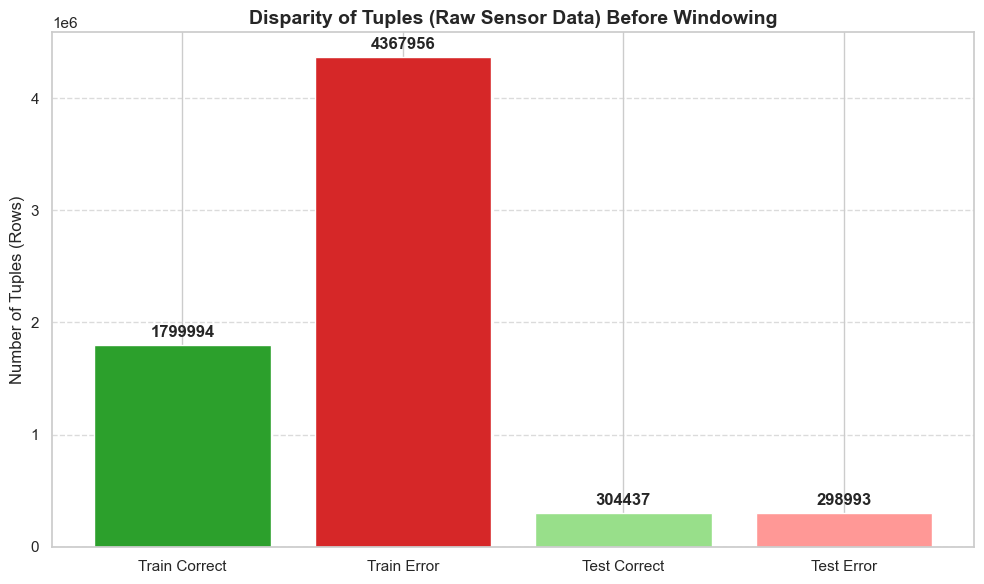

In [44]:
# Calculate total tuples for Training Set
correct_train_tuples = sum(len(df) for df in correct_train_list)
error_train_tuples = sum(len(df) for df in error_train_list)

# Calculate total tuples for Test Set
correct_test_tuples = sum(len(df) for df in correct_test_list)
error_test_tuples = sum(len(df) for df in error_test_list)

# Calculate overall totals
total_correct = correct_train_tuples + correct_test_tuples
total_error = error_train_tuples + error_test_tuples
total_tuples = total_correct + total_error

print(f"TRAIN SET:")
print(f"  Correct Print Tuples : {correct_train_tuples}")
print(f"  Error Print Tuples   : {error_train_tuples}")
print(f"  Disparity            : {abs(correct_train_tuples - error_train_tuples)} tuples")

print(f"\nTEST SET:")
print(f"  Correct Print Tuples : {correct_test_tuples}")
print(f"  Error Print Tuples   : {error_test_tuples}")
print(f"  Disparity            : {abs(correct_test_tuples - error_test_tuples)} tuples")

print(f"\nOVERALL:")
print(f"  Total Correct Tuples : {total_correct} ({round((total_correct/total_tuples)*100, 2)}%)")
print(f"  Total Error Tuples   : {total_error} ({round((total_error/total_tuples)*100, 2)}%)")

# VISUALIZE THE DISPARITY
labels = ['Train Correct', 'Train Error', 'Test Correct', 'Test Error']
values = [correct_train_tuples, error_train_tuples, correct_test_tuples, error_test_tuples]
colors = ['#2ca02c', '#d62728', '#98df8a', '#ff9896'] # Green for correct, Red for errors

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)

# Add exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(values)*0.01), 
             int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Disparity of Tuples (Raw Sensor Data) Before Windowing', fontsize=14, fontweight='bold')
plt.ylabel('Number of Tuples (Rows)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Random Forest

In [45]:
print("Starting Nested Hyperparameter Tuning (Windowing + Random Forest)...")

# Random Forest parameter grid
rf_param_grid = {
    'n_estimators': [25, 30, 35, 40, 45, 50],   
    'max_depth': [3, 4, 5, 8],              
    'criterion': ['gini', 'entropy']            
}

# RANDOM FOREST TUNING LOOP
best_rf_test_accuracy = 0
rf_cv_accuracy = 0
best_rf_params = {}
best_rf_window_config = {}
best_rf_model = None
best_rf_dataset = None

rf_estimator = RandomForestClassifier(random_state=42, bootstrap=True, class_weight='balanced', n_jobs=-1)

for config in window_configs:
    start_time = time.time()
    w_name = config['name']
    w_size = config['window_size']
    s_size = config['step_size']
    
    print(f"\n{'='*79}")
    print(f"= --- Testing Window Config: {w_name} (Window: {w_size}, Step: {s_size}) --- =")
    print(f"{'='*79}")
    
    # Extract Train and Test Windows
    group_counter = 0

    correct_windows, group_counter = extract_features_for_tuning(
        correct_train_list, 0, w_size, s_size, group_counter
    )

    error_windows, group_counter = extract_features_for_tuning(
        error_train_list, 1, w_size, s_size, group_counter
    )

    train_windows = correct_windows + error_windows

    test_ok = extract_features_for_tuning(correct_test_list, 0, w_size, s_size)[0]
    test_err = extract_features_for_tuning(error_test_list, 1, w_size, s_size)[0]
    
    df_train = pd.DataFrame(train_windows)
    df_test = pd.DataFrame(test_ok + test_err)
    
    if len(df_train) == 0 or len(df_test) == 0:
        print("  Skipping: Not enough data for this window size.")
        continue
        
    X_train = df_train.drop(columns=['Label', 'Group'])
    y_train = df_train['Label']
    groups = df_train['Group']
    
    X_test = df_test.drop(columns=['Label', 'Group'], errors='ignore')
    y_test = df_test['Label']
    
    print(f"  Train windows: {len(X_train)} | Test windows: {len(X_test)}")
    print(f"  -> Tuning Random Forest...")
    
    search = GridSearchCV(
        estimator=rf_estimator, 
        param_grid=rf_param_grid,
        cv=cv_strategy, 
        scoring='accuracy', 
        n_jobs=-1
    )
    
    # Train and tune on Training Data ONLY
    search.fit(X_train, y_train, groups=groups)
    current_cv_acc = search.best_score_
    
    # Evaluate the best tuned model on the unseen Test Data
    best_model_for_window = search.best_estimator_
    y_pred_test = best_model_for_window.predict(X_test)
    current_test_acc = accuracy_score(y_test, y_pred_test)
    
    print(f"     CV Accuracy: {current_cv_acc:.4f} | Test Accuracy: {current_test_acc:.4f}")
    
    # Selection based on TEST Accuracy
    if current_test_acc > best_rf_test_accuracy or (current_test_acc == best_rf_test_accuracy and current_cv_acc > rf_cv_accuracy):
        best_rf_test_accuracy = current_test_acc
        rf_cv_accuracy = current_cv_acc
        best_rf_params = search.best_params_
        best_rf_window_config = config
        best_rf_model = best_model_for_window
        best_rf_dataset = pd.concat([df_train, df_test], ignore_index=True)
            
    elapsed_time = time.time() - start_time
    print(f"  [Window config evaluated in {elapsed_time:.1f} seconds]")

print("\n--- RANDOM FOREST: BEST OVERALL CONFIGURATION ---")
print(f"Best Window Size: {best_rf_window_config.get('window_size', 'N/A')} samples")
print(f"Best Target Accuracy (Test): {best_rf_test_accuracy:.4f}")

# Save the best RF result into a dictionary for final comparison
best_rf_result = {
    'name': 'Random Forest',
    'accuracy': best_rf_test_accuracy,
    'model': best_rf_model,
    'dataset': best_rf_dataset,
    'config': best_rf_window_config
}

Starting Nested Hyperparameter Tuning (Windowing + Random Forest)...

= --- Testing Window Config: 5.0_Sec_00%_Overlap (Window: 980, Step: 980) --- =
  Train windows: 6288 | Test windows: 613
  -> Tuning Random Forest...
     CV Accuracy: 0.6453 | Test Accuracy: 0.8173
  [Window config evaluated in 55.2 seconds]

= --- Testing Window Config: 5.0_Sec_10%_Overlap (Window: 980, Step: 880) --- =
  Train windows: 7003 | Test windows: 683
  -> Tuning Random Forest...
     CV Accuracy: 0.6594 | Test Accuracy: 0.8155
  [Window config evaluated in 48.2 seconds]

= --- Testing Window Config: 5.0_Sec_25%_Overlap (Window: 980, Step: 730) --- =
  Train windows: 8441 | Test windows: 823
  -> Tuning Random Forest...
     CV Accuracy: 0.6425 | Test Accuracy: 0.8080
  [Window config evaluated in 57.3 seconds]

= --- Testing Window Config: 5.0_Sec_50%_Overlap (Window: 980, Step: 490) --- =
  Train windows: 12569 | Test windows: 1225
  -> Tuning Random Forest...
     CV Accuracy: 0.6500 | Test Accuracy: 

## Extra Trees

In [46]:
print("\nStarting Nested Hyperparameter Tuning (Windowing + Extra Trees)...")

# Extra Trees parameter grid
et_param_grid = {
    'n_estimators': [25, 30, 35, 40, 45, 50],   
    'max_depth': [3, 5, 8],                   
    'criterion': ['gini', 'entropy']            
}

# EXTRA TREES TUNING LOOP
best_et_test_accuracy = 0
et_cv_accuracy = 0
best_et_params = {}
best_et_window_config = {}
best_et_model = None
best_et_dataset = None

et_estimator = ExtraTreesClassifier(random_state=42, bootstrap=False, class_weight='balanced', n_jobs=-1)

for config in window_configs:
    start_time = time.time()
    w_name = config['name']
    w_size = config['window_size']
    s_size = config['step_size']
    
    print(f"\n{'='*79}")
    print(f"= --- Testing Window Config: {w_name} (Window: {w_size}, Step: {s_size}) --- =")
    print(f"{'='*79}")

    # Extract Train and Test Windows
    group_counter = 0

    correct_windows, group_counter = extract_features_for_tuning(
        correct_train_list, 0, w_size, s_size, group_counter
    )

    error_windows, group_counter = extract_features_for_tuning(
        error_train_list, 1, w_size, s_size, group_counter
    )

    train_windows = correct_windows + error_windows

    test_ok = extract_features_for_tuning(correct_test_list, 0, w_size, s_size)[0]
    test_err = extract_features_for_tuning(error_test_list, 1, w_size, s_size)[0]
    
    df_train = pd.DataFrame(train_windows)
    df_test = pd.DataFrame(test_ok + test_err)
    
    if len(df_train) == 0 or len(df_test) == 0:
        print("  Skipping: Not enough data for this window size.")
        continue
        
    X_train = df_train.drop(columns=['Label', 'Group'])
    y_train = df_train['Label']
    groups = df_train['Group']
    
    X_test = df_test.drop(columns=['Label', 'Group'], errors='ignore')
    y_test = df_test['Label']
    
    print(f"  Train windows: {len(X_train)} | Test windows: {len(X_test)}")
    print(f"  -> Tuning Extra Trees...")
    
    search = GridSearchCV(
        estimator=et_estimator, 
        param_grid=et_param_grid,
        cv=cv_strategy, 
        scoring='accuracy', 
        n_jobs=-1
    )
    
    # Train and tune on Training Data ONLY
    search.fit(X_train, y_train, groups=groups)
    current_cv_acc = search.best_score_
    
    # Evaluate the best tuned model on the unseen Test Data
    best_model_for_window = search.best_estimator_
    y_pred_test = best_model_for_window.predict(X_test)
    current_test_acc = accuracy_score(y_test, y_pred_test)
    
    print(f"     CV Accuracy: {current_cv_acc:.4f} | Test Accuracy: {current_test_acc:.4f}")
    
    # Selection based on TEST Accuracy
    if current_test_acc > best_et_test_accuracy or (current_test_acc == best_et_test_accuracy and current_cv_acc > et_cv_accuracy):
        best_et_test_accuracy = current_test_acc
        et_cv_accuracy = current_cv_acc
        best_et_params = search.best_params_
        best_et_window_config = config
        best_et_model = best_model_for_window
        best_et_dataset = pd.concat([df_train, df_test], ignore_index=True)
            
    elapsed_time = time.time() - start_time
    print(f"  [Window config evaluated in {elapsed_time:.1f} seconds]")

print("\n--- EXTRA TREES: BEST OVERALL CONFIGURATION ---")
print(f"Best Window Size: {best_et_window_config.get('window_size', 'N/A')} samples")
print(f"Best Target Accuracy (Test): {best_et_test_accuracy:.4f}")

# Save the best ET result into a dictionary for final comparison
best_et_result = {
    'name': 'Extra Trees',
    'accuracy': best_et_test_accuracy,
    'model': best_et_model,
    'dataset': best_et_dataset,
    'config': best_et_window_config,
}


Starting Nested Hyperparameter Tuning (Windowing + Extra Trees)...

= --- Testing Window Config: 5.0_Sec_00%_Overlap (Window: 980, Step: 980) --- =
  Train windows: 6288 | Test windows: 613
  -> Tuning Extra Trees...
     CV Accuracy: 0.5888 | Test Accuracy: 0.4046
  [Window config evaluated in 11.9 seconds]

= --- Testing Window Config: 5.0_Sec_10%_Overlap (Window: 980, Step: 880) --- =
  Train windows: 7003 | Test windows: 683
  -> Tuning Extra Trees...
     CV Accuracy: 0.5726 | Test Accuracy: 0.6618
  [Window config evaluated in 11.5 seconds]

= --- Testing Window Config: 5.0_Sec_25%_Overlap (Window: 980, Step: 730) --- =
  Train windows: 8441 | Test windows: 823
  -> Tuning Extra Trees...
     CV Accuracy: 0.5811 | Test Accuracy: 0.6233
  [Window config evaluated in 11.6 seconds]

= --- Testing Window Config: 5.0_Sec_50%_Overlap (Window: 980, Step: 490) --- =
  Train windows: 12569 | Test windows: 1225
  -> Tuning Extra Trees...
     CV Accuracy: 0.5902 | Test Accuracy: 0.6131
  

## Neural Network

In [47]:
def plot_training_history(history, title):
    """Plots the training loss, validation loss, and learning rate."""
    
    # Extract loss values from the training history object [cite: 1338-1339]
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    # Extract the learning rate
    # Note: depending on the Keras version, it might be keyed as 'lr' or 'learning_rate'
    learning_rate = history.history.get('learning_rate', history.history.get('lr'))
    
    # Get the actual number of epochs trained [cite: 1341]
    epochs = range(1, len(train_loss) + 1)
    
    # Set up the figure and the primary axis
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Plot Loss on the primary Y-axis (Left)
    ax1.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_loss, 'r--', label='Validation Loss', linewidth=2)
    
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss (Binary Crossentropy)', fontsize=12, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot Learning Rate on the secondary Y-axis (Right)
    if learning_rate is not None:
        # Create a twin axis sharing the same X-axis
        ax2 = ax1.twinx()  
        
        # Plot the learning rate in green
        ax2.plot(epochs, learning_rate, 'g-', label='Learning Rate', linewidth=2)
        ax2.set_ylabel('Learning Rate (Log Scale)', fontsize=12, color='green')
        ax2.tick_params(axis='y', labelcolor='green')
        
        # Use a logarithmic scale for the learning rate Y-axis
        ax2.set_yscale('log') 
        
        # Combine legends from both axes into a single legend box
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=12)
    else:
        # Fallback legend if no learning rate is found [cite: 1346]
        ax1.legend(loc='upper right', fontsize=12)
    
    # Add the main title [cite: 1345]
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Display the plot cleanly [cite: 1351-1352]
    fig.tight_layout()
    plt.show()

In [48]:
"""
def build_nn_1_sec(input_features):
    activation_function = tf.keras.activations.relu
    
    l2_reg = regularizers.l2(0.005)

    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_features,)),
        
        # First Hidden Layer
        tf.keras.layers.Dense(64, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.2),
        
        # Second Hidden Layer
        tf.keras.layers.Dense(32, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.2),
        
        # Third Hidden Layer
        tf.keras.layers.Dense(16, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.2),
        
        # Output Layer
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model
"""

def build_nn_5_sec(input_features):
    # 5 seconds window
    activation_function = tf.keras.activations.relu
    l2_reg = regularizers.l2(0.01)

    model = tf.keras.Sequential([
        # Input Layer mapping the 35 extracted features
        tf.keras.layers.InputLayer(input_shape=(input_features,)),
        
        # First Hidden Layer: Wider to capture complex relationships in tabular data
        tf.keras.layers.Dense(64, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.2),
        
        # Second Hidden Layer: Feature condensation
        tf.keras.layers.Dense(32, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.2),
        
        # Third Hidden Layer: Final abstraction
        tf.keras.layers.Dense(16, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.2),
        
        # Output Layer: Single node for binary prediction 
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Adaptive optimizer with an explicitly defined learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

"""
def build_nn_10_sec(input_features):
    activation_function = tf.keras.activations.relu
    
    # Increased L2 regularization to constrain weights on smaller dataset
    l2_reg = regularizers.l2(0.015)

    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_features,)),
        
        # First Hidden Layer: Narrower starting point
        tf.keras.layers.Dense(32, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.3), 
        
        # Second Hidden Layer: Direct abstraction
        tf.keras.layers.Dense(16, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.3),
        
        # Output Layer
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_nn_15_sec(input_features):
    activation_function = tf.keras.activations.relu
    l2_reg = regularizers.l2(0.05) # Very aggressive L2 regularization

    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(input_features,)),
        
        # First Hidden Layer: Narrower starting point
        tf.keras.layers.Dense(16, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.3), 
        
        # Second Hidden Layer: Direct abstraction
        tf.keras.layers.Dense(8, activation=activation_function, kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.3),
        
        # Output Layer
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5) # Very slow learning to avoid jumping the local minima
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model
"""

"\ndef build_nn_10_sec(input_features):\n    activation_function = tf.keras.activations.relu\n\n    # Increased L2 regularization to constrain weights on smaller dataset\n    l2_reg = regularizers.l2(0.015)\n\n    model = tf.keras.Sequential([\n        tf.keras.layers.InputLayer(input_shape=(input_features,)),\n\n        # First Hidden Layer: Narrower starting point\n        tf.keras.layers.Dense(32, activation=activation_function, kernel_regularizer=l2_reg),\n        tf.keras.layers.Dropout(0.3), \n\n        # Second Hidden Layer: Direct abstraction\n        tf.keras.layers.Dense(16, activation=activation_function, kernel_regularizer=l2_reg),\n        tf.keras.layers.Dropout(0.3),\n\n        # Output Layer\n        tf.keras.layers.Dense(1, activation='sigmoid')\n    ])\n\n    optimizer = tf.keras.optimizers.Adam(learning_rate=3e-5)\n    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])\n    return model\n\ndef build_nn_15_sec(input_features):\n    ac

In [49]:
def train_plot_evaluate_nn(w_name, w_size, s_size, model_builder_fn):
    print(f"\n{'='*81}")
    print(f"= --- Training Neural Network: {w_name} (Window: {w_size}, Step: {s_size}) --- =")
    print(f"{'='*81}")
    
    start_time = time.time()
    
    # Extract Train and Test Windows
    train_ok = extract_features_for_tuning(correct_train_list, 0, w_size, s_size)[0]
    train_err = extract_features_for_tuning(error_train_list, 1, w_size, s_size)[0]
    
    test_ok = extract_features_for_tuning(correct_test_list, 0, w_size, s_size)[0]
    test_err = extract_features_for_tuning(error_test_list, 1, w_size, s_size)[0]
    
    df_train = pd.DataFrame(train_ok + train_err)
    df_test = pd.DataFrame(test_ok + test_err)
    
    if len(df_train) == 0 or len(df_test) == 0:
        print("  Skipping: Not enough data for this window size.")
        return None
    
    X_train = df_train.drop(columns=['Label', 'Group'])
    y_train = df_train['Label']
    
    X_test = df_test.drop(columns=['Label', 'Group'], errors='ignore')
    y_test = df_test['Label']

    # Feature Scaling (Z-score normalization)    
    scaler = StandardScaler()
    
    # Fit on training data and transform both train and test sets
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Export parameters for the IoT Device (Formatted as C arrays)
    print("\n  -> [IoT EXPORT] StandardScaler Parameters:")
    means_str = ", ".join([f"{m:.6f}" for m in scaler.mean_])
    scales_str = ", ".join([f"{s:.6f}" for s in scaler.scale_])
    
    print(f"  float feature_means[{len(scaler.mean_)}] = {{{means_str}}};")
    print(f"  float feature_scales[{len(scaler.scale_)}] = {{{scales_str}}};\n")

    # Calculate Balanced Class Weights
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weights_dict = dict(zip(classes, weights))
    
    NB_features = X_train.shape[1]
    
    # Build Model dynamically using the passed function
    model = model_builder_fn(NB_features)

    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', # The metric to monitor
        factor=0.5,         # Factor by which the learning rate will be reduced (new_lr = lr * factor)
        patience=5,         # Number of epochs with no improvement after which lr will be reduced
        min_lr=1e-7,        # Lower bound on the learning rate
        verbose=1           # Print a message to the console when the lr is reduced
    )

    print(f"  Train windows: {len(X_train)} | Test windows: {len(X_test)}")
    print(f"  Class Weights: {class_weights_dict}")
    print("  -> Starting Training...")

    # Train the model with verbose=1 to see the epochs
    history = model.fit(
        x=X_train, 
        y=y_train,
        epochs=200, 
        validation_data=(X_test, y_test),
        class_weight=class_weights_dict, 
        callbacks=[early_stopping, reduce_lr], 
        verbose=1, 
        shuffle=False
    )

    # Evaluate
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    elapsed_time = time.time() - start_time
    print(f"  -> Test Loss: {loss:.4f} | Test Accuracy: {accuracy:.4f}")
    print(f"  [Evaluated in {elapsed_time:.1f} seconds]")
    
    # Plot training history IMMEDIATELY for this specific step/window
    plot_training_history(history, f"Training Profile - {w_name}")
    
    return {
        'name': 'Neural Network',
        'w_size': w_size,
        's_size': s_size,
        'accuracy': accuracy,
        'loss': loss,
        'model': model,
        'history': history,
        'config': {'name': w_name, 'window_size': w_size, 'step_size': s_size},
        'dataset': pd.concat([df_train, df_test], ignore_index=True),
        'scaler': scaler
    }

Starting Neural Network Training...

= --- Training Neural Network: 5.0_Sec_00%_Overlap (Window: 980, Step: 980) --- =

  -> [IoT EXPORT] StandardScaler Parameters:
  float feature_means[35] = {-0.218304, 0.159595, 0.599448, -1.012469, 1.611917, -0.203889, 0.149889, 0.690347, -1.043458, 1.733805, 9.644979, 0.058658, 10.142137, 9.251721, 0.890417, 0.270626, 0.601278, 4.725098, -4.231767, 8.956865, 0.337919, 0.626973, 5.142791, -4.629053, 9.771844, -9.847128, 0.369381, -7.921810, -11.730883, 3.809072, 340.318768, 9.175006, 356.011768, 318.576097, 37.435671};
  float feature_scales[35] = {0.079464, 0.088325, 0.608019, 0.468351, 0.998211, 0.031890, 0.082703, 0.756648, 0.555584, 1.209723, 0.028395, 0.063614, 0.609064, 0.755333, 1.284486, 0.030356, 0.337473, 2.208348, 2.125737, 4.147677, 0.024353, 0.349342, 2.367060, 2.344418, 4.489126, 0.052983, 0.182971, 2.037986, 1.353885, 3.316962, 40.685572, 14.659235, 38.940556, 53.870063, 38.673916};

  Train windows: 6288 | Test windows: 613
  Class 

c:\Users\Utente\anaconda3\envs\IoT\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4491 - loss: 1.7849 - val_accuracy: 0.5351 - val_loss: 1.7070 - learning_rate: 1.0000e-04
Epoch 2/200
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5329 - loss: 1.7021 - val_accuracy: 0.6134 - val_loss: 1.6691 - learning_rate: 1.0000e-04
Epoch 3/200
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5992 - loss: 1.6257 - val_accuracy: 0.6330 - val_loss: 1.6272 - learning_rate: 1.0000e-04
Epoch 4/200
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6411 - loss: 1.5612 - val_accuracy: 0.6378 - val_loss: 1.5775 - learning_rate: 1.0000e-04
Epoch 5/200
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6788 - loss: 1.4968 - val_accuracy: 0.6395 - val_loss: 1.5321 - learning_rate: 1.0000e-04
Epoch 6/200
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7126 - loss: 1.4335 - val_accuracy: 0.6460 - val_loss: 1.4920 - learning_rate: 1.0000e-04
Epoch 7/200
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.726

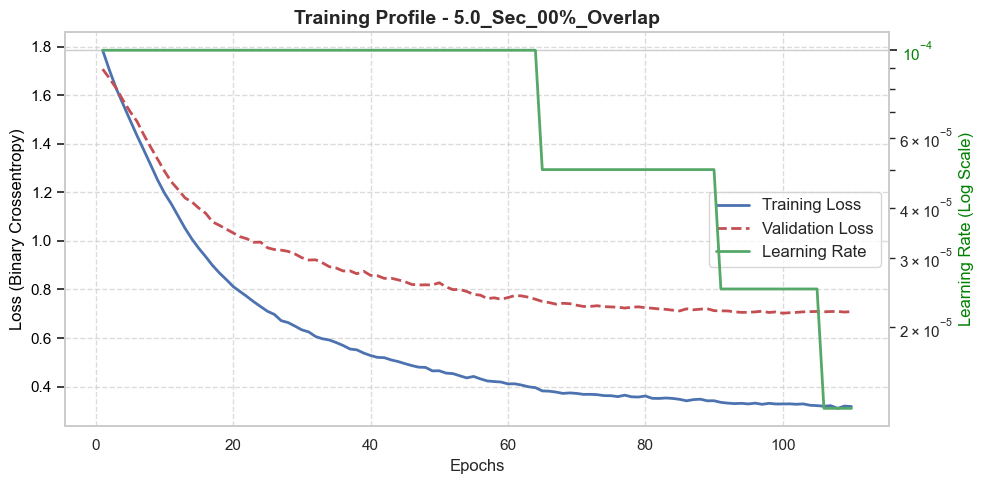


= --- Training Neural Network: 5.0_Sec_10%_Overlap (Window: 980, Step: 880) --- =

  -> [IoT EXPORT] StandardScaler Parameters:
  float feature_means[35] = {-0.218290, 0.159460, 0.597476, -1.010435, 1.607910, -0.203900, 0.149822, 0.690317, -1.042742, 1.733060, 9.644996, 0.058395, 10.138146, 9.257201, 0.880945, 0.270599, 0.600927, 4.724618, -4.228921, 8.953539, 0.337949, 0.626036, 5.127375, -4.624614, 9.751988, -9.847129, 0.369160, -7.926109, -11.727709, 3.801599, 340.306801, 9.184082, 356.034557, 318.561959, 37.472597};
  float feature_scales[35] = {0.079440, 0.088439, 0.616400, 0.453011, 0.991163, 0.031953, 0.083855, 0.755684, 0.558930, 1.214649, 0.028403, 0.064212, 0.607137, 0.743571, 1.271451, 0.029769, 0.337427, 2.203878, 2.126323, 4.140789, 0.024354, 0.348810, 2.361546, 2.340313, 4.478535, 0.053011, 0.182744, 2.027233, 1.346646, 3.297971, 40.689756, 14.692342, 38.951132, 53.910604, 38.703452};

  Train windows: 7003 | Test windows: 683
  Class Weights: {np.int64(0): np.float64(1.

c:\Users\Utente\anaconda3\envs\IoT\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4398 - loss: 1.7746 - val_accuracy: 0.4963 - val_loss: 1.7274 - learning_rate: 1.0000e-04
Epoch 2/200
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4888 - loss: 1.6849 - val_accuracy: 0.4539 - val_loss: 1.6485 - learning_rate: 1.0000e-04
Epoch 3/200
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5710 - loss: 1.5882 - val_accuracy: 0.4436 - val_loss: 1.5766 - learning_rate: 1.0000e-04
Epoch 4/200
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6207 - loss: 1.5114 - val_accuracy: 0.4627 - val_loss: 1.5095 - learning_rate: 1.0000e-04
Epoch 5/200
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6570 - loss: 1.4379 - val_accuracy: 0.5022 - val_loss: 1.4497 - learning_rate: 1.0000e-04
Epoch 6/200
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6934 - loss: 1.3713 - val_accuracy: 0.5783 - val_loss: 1.3883 - learning_rate: 1.0000e-04
Epoch 7/200
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.725

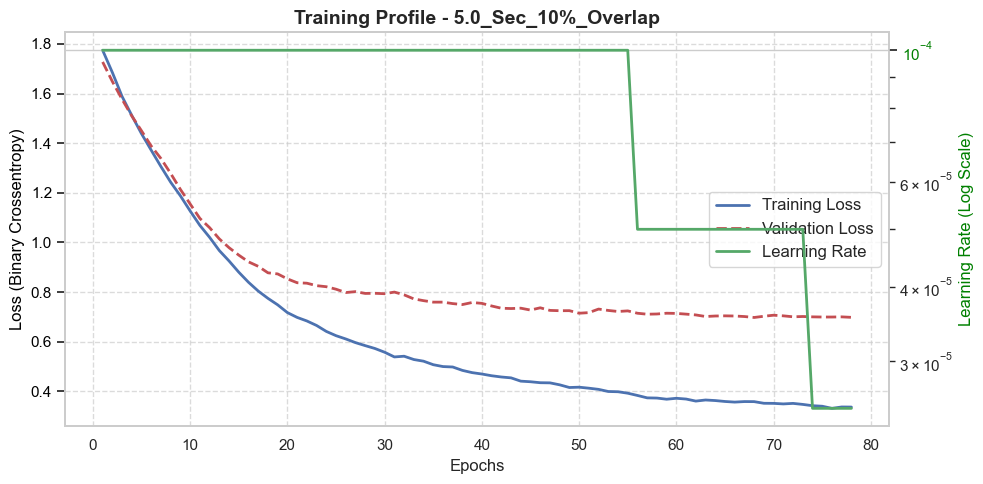


= --- Training Neural Network: 5.0_Sec_25%_Overlap (Window: 980, Step: 730) --- =

  -> [IoT EXPORT] StandardScaler Parameters:
  float feature_means[35] = {-0.218206, 0.159235, 0.595087, -1.007821, 1.602908, -0.203864, 0.149543, 0.686141, -1.040523, 1.726664, 9.644999, 0.058246, 10.137125, 9.260757, 0.876368, 0.270437, 0.600802, 4.728377, -4.233866, 8.962243, 0.338149, 0.626262, 5.132610, -4.613459, 9.746070, -9.847269, 0.369104, -7.920147, -11.731980, 3.811833, 340.332002, 9.149821, 356.023706, 318.593887, 37.429819};
  float feature_scales[35] = {0.079356, 0.087854, 0.596125, 0.437911, 0.957044, 0.031891, 0.082566, 0.729662, 0.545324, 1.184052, 0.028401, 0.062445, 0.593682, 0.713398, 1.230110, 0.030245, 0.336523, 2.200066, 2.126757, 4.140374, 0.024441, 0.348618, 2.363519, 2.330185, 4.469026, 0.052954, 0.182573, 2.045285, 1.355012, 3.324264, 40.677760, 14.628989, 38.957112, 53.860872, 38.661475};

  Train windows: 8441 | Test windows: 823
  Class Weights: {np.int64(0): np.float64(1.

c:\Users\Utente\anaconda3\envs\IoT\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4440 - loss: 1.7871 - val_accuracy: 0.7752 - val_loss: 1.5666 - learning_rate: 1.0000e-04
Epoch 2/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5261 - loss: 1.6875 - val_accuracy: 0.7825 - val_loss: 1.5457 - learning_rate: 1.0000e-04
Epoch 3/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6070 - loss: 1.5983 - val_accuracy: 0.7521 - val_loss: 1.5187 - learning_rate: 1.0000e-04
Epoch 4/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6747 - loss: 1.5088 - val_accuracy: 0.7108 - val_loss: 1.4840 - learning_rate: 1.0000e-04
Epoch 5/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7055 - loss: 1.4372 - val_accuracy: 0.6671 - val_loss: 1.4471 - learning_rate: 1.0000e-04
Epoch 6/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7448 - loss: 1.3573 - val_accuracy: 0.6513 - val_loss: 1.4044 - learning_rate: 1.0000e-04
Epoch 7/200
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.771

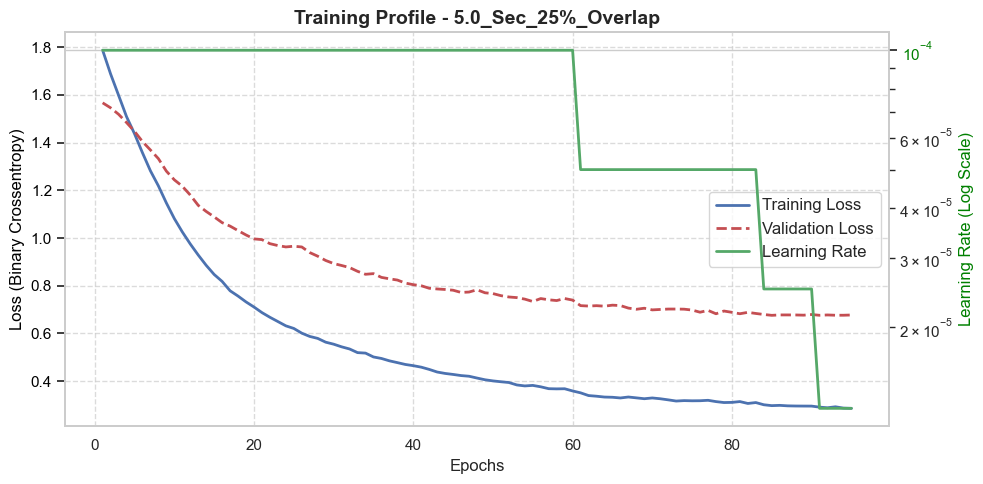


= --- Training Neural Network: 5.0_Sec_50%_Overlap (Window: 980, Step: 490) --- =

  -> [IoT EXPORT] StandardScaler Parameters:
  float feature_means[35] = {-0.218217, 0.159600, 0.599071, -1.013083, 1.612154, -0.203888, 0.149864, 0.690659, -1.043839, 1.734498, 9.644989, 0.058593, 10.139960, 9.252877, 0.887082, 0.270649, 0.601384, 4.724385, -4.232856, 8.957241, 0.337948, 0.627073, 5.141791, -4.629911, 9.771702, -9.847126, 0.369370, -7.921679, -11.732397, 3.810718, 340.357795, 9.162922, 356.080547, 318.624481, 37.456067};
  float feature_scales[35] = {0.079204, 0.088306, 0.605875, 0.471537, 0.998316, 0.031863, 0.082708, 0.757504, 0.557242, 1.213327, 0.028396, 0.063655, 0.608207, 0.758792, 1.287966, 0.030018, 0.337478, 2.210056, 2.124281, 4.147805, 0.024296, 0.349277, 2.366793, 2.344905, 4.488981, 0.053004, 0.182960, 2.037817, 1.355107, 3.317393, 40.651136, 14.644025, 38.892676, 53.847709, 38.677757};

  Train windows: 12569 | Test windows: 1225
  Class Weights: {np.int64(0): np.float64(

c:\Users\Utente\anaconda3\envs\IoT\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4735 - loss: 1.7406 - val_accuracy: 0.5363 - val_loss: 1.6869 - learning_rate: 1.0000e-04
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6177 - loss: 1.5965 - val_accuracy: 0.6057 - val_loss: 1.6089 - learning_rate: 1.0000e-04
Epoch 3/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7121 - loss: 1.4672 - val_accuracy: 0.5755 - val_loss: 1.5503 - learning_rate: 1.0000e-04
Epoch 4/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7642 - loss: 1.3432 - val_accuracy: 0.6098 - val_loss: 1.4722 - learning_rate: 1.0000e-04
Epoch 5/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8010 - loss: 1.2315 - val_accuracy: 0.6449 - val_loss: 1.4148 - learning_rate: 1.0000e-04
Epoch 6/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8235 - loss: 1.1248 - val_accuracy: 0.6833 - val_loss: 1.3431 - learning_rate: 1.0000e-04
Epoch 7/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.845

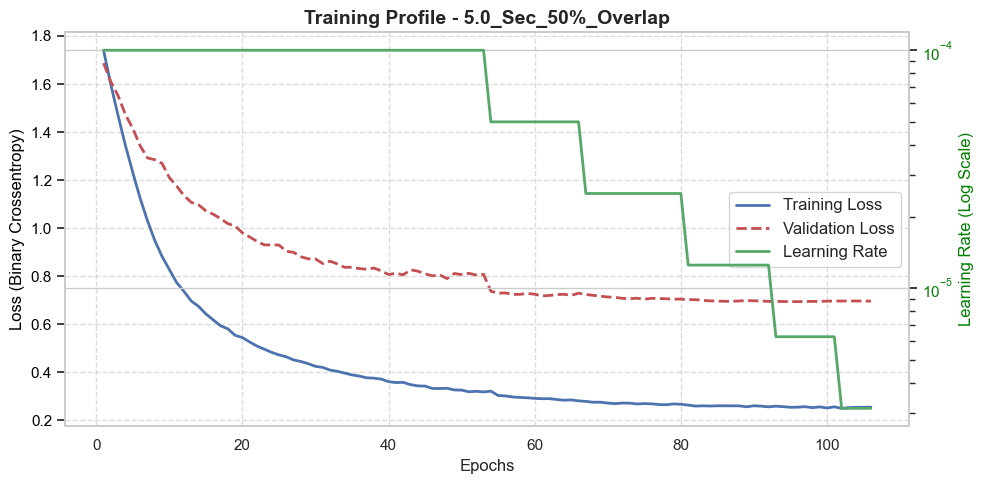

"\n# --- 10.0 Seconds Window (1955 samples) ---\nres_10s_00 = train_plot_evaluate_nn('10.0_Sec_00%_Overlap', 1955, 1955, build_nn_10_sec)\nres_10s_10 = train_plot_evaluate_nn('10.0_Sec_10%_Overlap', 1955, 1760, build_nn_10_sec)\nres_10s_25 = train_plot_evaluate_nn('10.0_Sec_25%_Overlap', 1955, 1465, build_nn_10_sec)\nres_10s_50 = train_plot_evaluate_nn('10.0_Sec_50%_Overlap', 1955, 975, build_nn_10_sec)\n\n# --- 15.0 Seconds Window (2935 samples) ---\nres_15s_00 = train_plot_evaluate_nn('15.0_Sec_00%_Overlap', 2935, 2935, build_nn_15_sec)\nres_15s_10 = train_plot_evaluate_nn('15.0_Sec_10%_Overlap', 2935, 2640, build_nn_15_sec)\nres_15s_25 = train_plot_evaluate_nn('15.0_Sec_25%_Overlap', 2935, 2200, build_nn_15_sec)\nres_15s_50 = train_plot_evaluate_nn('15.0_Sec_50%_Overlap', 2935, 1465, build_nn_15_sec)\n"

In [50]:
print("Starting Neural Network Training...")
"""
# --- 1.0 Second Window (195 samples) ---
res_1s_00 = train_plot_evaluate_nn('1.0_Sec_00%_Overlap', 195, 195, build_nn_1_sec)
res_1s_10 = train_plot_evaluate_nn('1.0_Sec_10%_Overlap', 195, 175, build_nn_1_sec)
res_1s_25 = train_plot_evaluate_nn('1.0_Sec_25%_Overlap', 195, 145, build_nn_1_sec)
res_1s_50 = train_plot_evaluate_nn('1.0_Sec_50%_Overlap', 195, 95, build_nn_1_sec)
"""

# --- 5.0 Seconds Window (970 samples) ---
res_5s_00 = train_plot_evaluate_nn('5.0_Sec_00%_Overlap', 980, 980, build_nn_5_sec)
res_5s_10 = train_plot_evaluate_nn('5.0_Sec_10%_Overlap', 980, 880, build_nn_5_sec)
res_5s_25 = train_plot_evaluate_nn('5.0_Sec_25%_Overlap', 980, 730, build_nn_5_sec)
res_5s_50 = train_plot_evaluate_nn('5.0_Sec_50%_Overlap', 980, 490, build_nn_5_sec)

"""
# --- 10.0 Seconds Window (1955 samples) ---
res_10s_00 = train_plot_evaluate_nn('10.0_Sec_00%_Overlap', 1955, 1955, build_nn_10_sec)
res_10s_10 = train_plot_evaluate_nn('10.0_Sec_10%_Overlap', 1955, 1760, build_nn_10_sec)
res_10s_25 = train_plot_evaluate_nn('10.0_Sec_25%_Overlap', 1955, 1465, build_nn_10_sec)
res_10s_50 = train_plot_evaluate_nn('10.0_Sec_50%_Overlap', 1955, 975, build_nn_10_sec)

# --- 15.0 Seconds Window (2935 samples) ---
res_15s_00 = train_plot_evaluate_nn('15.0_Sec_00%_Overlap', 2935, 2935, build_nn_15_sec)
res_15s_10 = train_plot_evaluate_nn('15.0_Sec_10%_Overlap', 2935, 2640, build_nn_15_sec)
res_15s_25 = train_plot_evaluate_nn('15.0_Sec_25%_Overlap', 2935, 2200, build_nn_15_sec)
res_15s_50 = train_plot_evaluate_nn('15.0_Sec_50%_Overlap', 2935, 1465, build_nn_15_sec)
"""

In [51]:
def get_best_for_window(results_list):
    valid_results = [res for res in results_list if res is not None]
    if not valid_results:
        return None
    # Sort by highest accuracy, then by lowest loss
    valid_results.sort(key=lambda x: (x['accuracy'], -x['loss']), reverse=True)
    return valid_results[0]

best_nn_result = get_best_for_window([res_5s_00, res_5s_10, res_5s_25, res_5s_50])

if best_nn_result is not None:
    print("\n--- NEURAL NETWORK: BEST OVERALL CONFIGURATION ---")
    print(f"Best Window Size: {best_nn_result['w_size']} samples")
    print(f"Test Accuracy: {best_nn_result['accuracy']:.4f} | Test Loss: {best_nn_result['loss']:.4f}")


--- NEURAL NETWORK: BEST OVERALL CONFIGURATION ---
Best Window Size: 980 samples
Test Accuracy: 0.8311 | Test Loss: 0.6760


## Tiny ML

In [52]:
def export_scaler_to_c(scaler, output_filename="model/scaler_params.h"):
    """
    Extracts mean and scale from a StandardScaler and writes them to a C header file.
    """
    means = scaler.mean_
    scales = scaler.scale_
    num_features = len(means)
    
    with open(output_filename, "w") as f:
        f.write("/* Auto-generated Scaler Parameters */\n")
        f.write("#ifndef SCALER_PARAMS_H\n")
        f.write("#define SCALER_PARAMS_H\n\n")
        
        f.write(f"#define NUM_FEATURES {num_features}\n\n")
        
        # Write the Means array
        f.write(f"const float SCALER_MEANS[{num_features}] = {{\n    ")
        f.write(", ".join([f"{val:.6f}f" for val in means]))
        f.write("\n};\n\n")
        
        # Write the Scales (Standard Deviations) array
        f.write(f"const float SCALER_SCALES[{num_features}] = {{\n    ")
        f.write(", ".join([f"{val:.6f}f" for val in scales]))
        f.write("\n};\n\n")
        
        f.write("#endif // SCALER_PARAMS_H\n")

In [53]:
print("\n\n" + "="*49)
print("=    OVERALL BEST MODEL SELECTION AND EXPORT    =")
print("="*49)

# Gather all successful models
all_models = []
if best_rf_result['model'] is not None: all_models.append(best_rf_result)
if best_et_result['model'] is not None: all_models.append(best_et_result)
if best_nn_result is not None: all_models.append(best_nn_result)

# SAVE ALL MODELS IN STANDARD FORMAT
print("\nSaving All Trained Models:")
for result in all_models:
    current_model_type = result['name']
    current_model = result['model']
    
    if current_model_type in ['Random Forest', 'Extra Trees']:
        model_path_pkl = f'model/{current_model_type.replace(" ", "_").lower()}_model.pkl'
        joblib.dump(current_model, model_path_pkl)
        print(f"  [OK] Saved standard Python model: {model_path_pkl}")
        
    elif current_model_type == 'Neural Network':
        model_path_keras = 'model/nn_model.keras'
        current_model.save(model_path_keras)
        print(f"  [OK] Saved standard Keras NN model: {model_path_keras}")

# SELECT THE BEST OVERALL MODEL
# Sort by accuracy
all_models.sort(key=lambda x: x['accuracy'], reverse=True)

best_overall = all_models[0]
best_model_type = best_overall['name']
final_model = best_overall['model']
final_dataset = best_overall['dataset']

print(f"\n[WINNER] The best performing algorithm is: {best_model_type}")
print(f"[WINNER] Final Test Accuracy: {best_overall['accuracy']:.4f}")
print(f"[WINNER] Configuration: {best_overall['config']['name']}\n")

# Save the best generated dataset
dataset_path = 'data/best_window_dataset.csv'
final_dataset.to_csv(dataset_path, index=False)
print(f"  [OK] Saved best dataset to: {dataset_path}")

# EXPORT ONLY THE BEST MODEL AS .h FOR EDGE IOT
print("\nExporting Best Model for Edge IoT (.h):")
model_path_h = 'model/print_prediction.h'

if best_model_type in ['Random Forest', 'Extra Trees']:
    # Save TinyML C Header using emlearn inline method
    cmodel = emlearn.convert(final_model, method='inline')
    cmodel.save(file=model_path_h, name='print_prediction')
    print(f"  [OK] Saved TinyML C header (emlearn) for Edge IoT to: {model_path_h}")

elif best_model_type == 'Neural Network':
    # Convert the model to TensorFlow Lite, then to a C byte array
    print("  -> Converting Neural Network to TensorFlow Lite C Array...")
    final_scaler = best_overall.get('scaler', None)
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
        # Optional: Add post-training quantization for microcontrollers
        # converter.optimizations = [tf.lite.Optimize.DEFAULT] 
        tflite_model = converter.convert()

        if final_scaler is not None:
            export_scaler_to_c(final_scaler, "model/scaler_params.h")
        
        # Convert TFLite binary to a C/C++ byte array for the .h file
        hex_array = ', '.join([f'0x{b:02x}' for b in tflite_model])
        
        with open(model_path_h, 'w') as f:
            f.write(f'// Automatically generated TensorFlow Lite Micro model\n')
            f.write(f'const unsigned char print_prediction[] = {{{hex_array}}};\n')
            f.write(f'const unsigned int print_prediction_len = {len(tflite_model)};\n')
            
        print(f"  [OK] Saved TinyML C header (TFLite byte array) for Edge IoT to: {model_path_h}")
        
    except Exception as e:
        print(f"  [!] Could not convert Neural Network to TFLite C array. Error: {e}")



=    OVERALL BEST MODEL SELECTION AND EXPORT    =

Saving All Trained Models:
  [OK] Saved standard Python model: model/random_forest_model.pkl
  [OK] Saved standard Python model: model/extra_trees_model.pkl
  [OK] Saved standard Keras NN model: model/nn_model.keras

[WINNER] The best performing algorithm is: Neural Network
[WINNER] Final Test Accuracy: 0.8311
[WINNER] Configuration: 5.0_Sec_25%_Overlap

  [OK] Saved best dataset to: data/best_window_dataset.csv

Exporting Best Model for Edge IoT (.h):
  -> Converting Neural Network to TensorFlow Lite C Array...
INFO:tensorflow:Assets written to: C:\Users\Utente\AppData\Local\Temp\tmpaefuednn\assets


INFO:tensorflow:Assets written to: C:\Users\Utente\AppData\Local\Temp\tmpaefuednn\assets


Saved artifact at 'C:\Users\Utente\AppData\Local\Temp\tmpaefuednn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 35), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2626869253840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2626869252496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2626869263824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2626869263632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2626869264016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2626869262288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2626869263440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2626869263248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  [OK] Saved TinyML C header (TFLite byte array) for Edge IoT to: model/print_prediction.h
